# 1. Decorator:
## A decorator is a function that takes another function as input and returns a new function.
2.3 Rückgabewert des Decorators
return myinner


⚠️ GANZ wichtig:

- Es wird nicht myinner() aufgerufen

- Es wird die Funktion selbst zurückgegeben

Das ist der Kern jedes Decorators.

@changecase
def myfunction():
    return "Hello Sally"

Das ist exakt gleichbedeutend mit:

- def myfunction():
    return "Hello Sally"

- **myfunction = changecase(myfunction)**

## 👉 myfunction wird ersetzt durch myinner

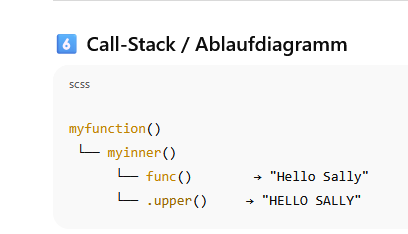





In [2]:
def changecase(func):
  def myinner():
    return func().upper()
  return myinner

@changecase
def myfunction():
  return "Hello Sally"
    
# 1. aufruf von myfunction(), 2. decorator: changecase(func) change (decorates) the result of myfunction()!!
# Rückgabewert des Decorators: myinner is a function
print(myfunction())


HELLO SALLY


# 2. Multiple Decorator Calls

In [3]:
def changecase(func):
  def myinner():
    return func().upper()
  return myinner

@changecase
def myfunction():
  return "Hello Sally"

@changecase
def otherfunction():
  return "I am speed!"

print(myfunction())  # myinner() uses original myfunction()
print(otherfunction()) #  # myinner() uses original otherfunction()

HELLO SALLY
I AM SPEED!


# 3. Arguments in the Decorated Function

In [4]:
def changecase(func):
  def myinner(x):
    return func(x).upper()
  return myinner

@changecase
def myfunction(nam):
  return "Hello " + nam

print(myfunction("John")) # call myinner(x)-> func(x)

HELLO JOHN


# 4. Typische Erweiterung: *args, **kwargs

Dein Decorator funktioniert nur für Funktionen ohne Parameter.

Produktionsreif wäre:

In [4]:
def changecase(func):
    def myinner(*args, **kwargs):
        return func(*args, **kwargs).upper()
    return myinner

@changecase
def myfunction():
  return "Hello Sally"
# myfunction() is now  myinner(), but myfunction will be used in myinner()
print(myfunction())

HELLO SALLY


In [ ]:
## myinner() uses original function()

In [5]:
def changecase(func):
  def myinner(*args, **kwargs):
    return func(*args, **kwargs).upper()
  return myinner

@changecase
def myfunction(nam):
  return "Hello " + nam

print(myfunction("John"))

HELLO JOHN


In [9]:
def myfunc(x,y,z):
 print( x+ " "+ y+" "+z)

myfunc("ich", "habe", "Zeit")

ich habe Zeit


# 5. Decorator With Arguments: Decorators can accept their own arguments by adding another wrapper level.
## myfunction = changecase(1)(myfunction)
-  myfunction= changecase(1)-> return a function with changecase(func)-> return myinner() ==> myfunction= myinner() with n=1 intern as case control

-  https://chatgpt.com/c/695174f6-4828-8333-a1e4-73a0c3430788

## 8️⃣ Kurzantwort auf die Kernfragen

✔ Ist myinner ein Wrapper?
→ Ja

✔ Ist das eine Closure?
→ Ja, sogar zwei Closure-Ebenen (n und func)

✔ Ersetzt Python myfunction?
→ Ja, myfunction zeigt danach auf myinner

✔ Warum Decorator mit Argumenten so aufgebaut?
→ Weil Python sonst nicht weiß, ob @changecase oder @changecase(1) gemeint ist

In [10]:
def changecase(n):
  def changecase(func):
    def myinner():
      if n == 1:
        a = func().lower()
      else:
        a = func().upper()
      return a
    return myinner
  return changecase

@changecase(1)
def myfunction():
  return "Hello Linus"

print(myfunction())

hello linus


# 6. Multiple Decorators
You can use multiple decorators on one function.

This is done by placing the decorator calls on top of each other.

Decorators are called in the reverse order, starting with the one closest to the function.

@A

@B

def f():
    ...


ist exakt dasselbe wie:

f = A(B(f))

myfunction == changecase(addgreeting(original_myfunction))

In [11]:
def changecase(func):
  def myinner():
    return func().upper()
  return myinner

def addgreeting(func):
  def myinner():
    return "Hello " + func() + " Have a good day!"
  return myinner

@changecase
@addgreeting
def myfunction():
  return "Tobias"

print(myfunction())

HELLO TOBIAS HAVE A GOOD DAY!


# 7. Preserving Function Metadata
Functions in Python has metadata that can be accessed using the __name__ and __doc__ attributes.

In [12]:
def myfunction():
  return "Have a great day!"

print(myfunction.__name__) 

myfunction


In [13]:
# But, when a function is decorated, the metadata of the original function is lost.
# myfunction=  changecase (myfunction) -> myinner()

def changecase(func):
  def myinner():
    return func().upper()
  return myinner

@changecase
def myfunction():
  return "Have a great day!"

print(myfunction.__name__)

myinner


## To fix this, Python has a built-in function called functools.wraps that can be used to preserve the original function's name and docstring.
from functools import wraps

@wraps(func)

def myinner():

In [14]:
import functools

def changecase(func):
  @functools.wraps(func)
  def myinner():
    return func().upper()
  return myinner

@changecase
def myfunction():
  return "Have a great day!"

print(myfunction.__name__)

myfunction
